<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_Kriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan pilih dan upload file 'meuse.txt' dari perangkat Anda:


Saving meuse.txt to meuse (4).txt

[INFO] Total data valid dimuat: 155 baris observasi.


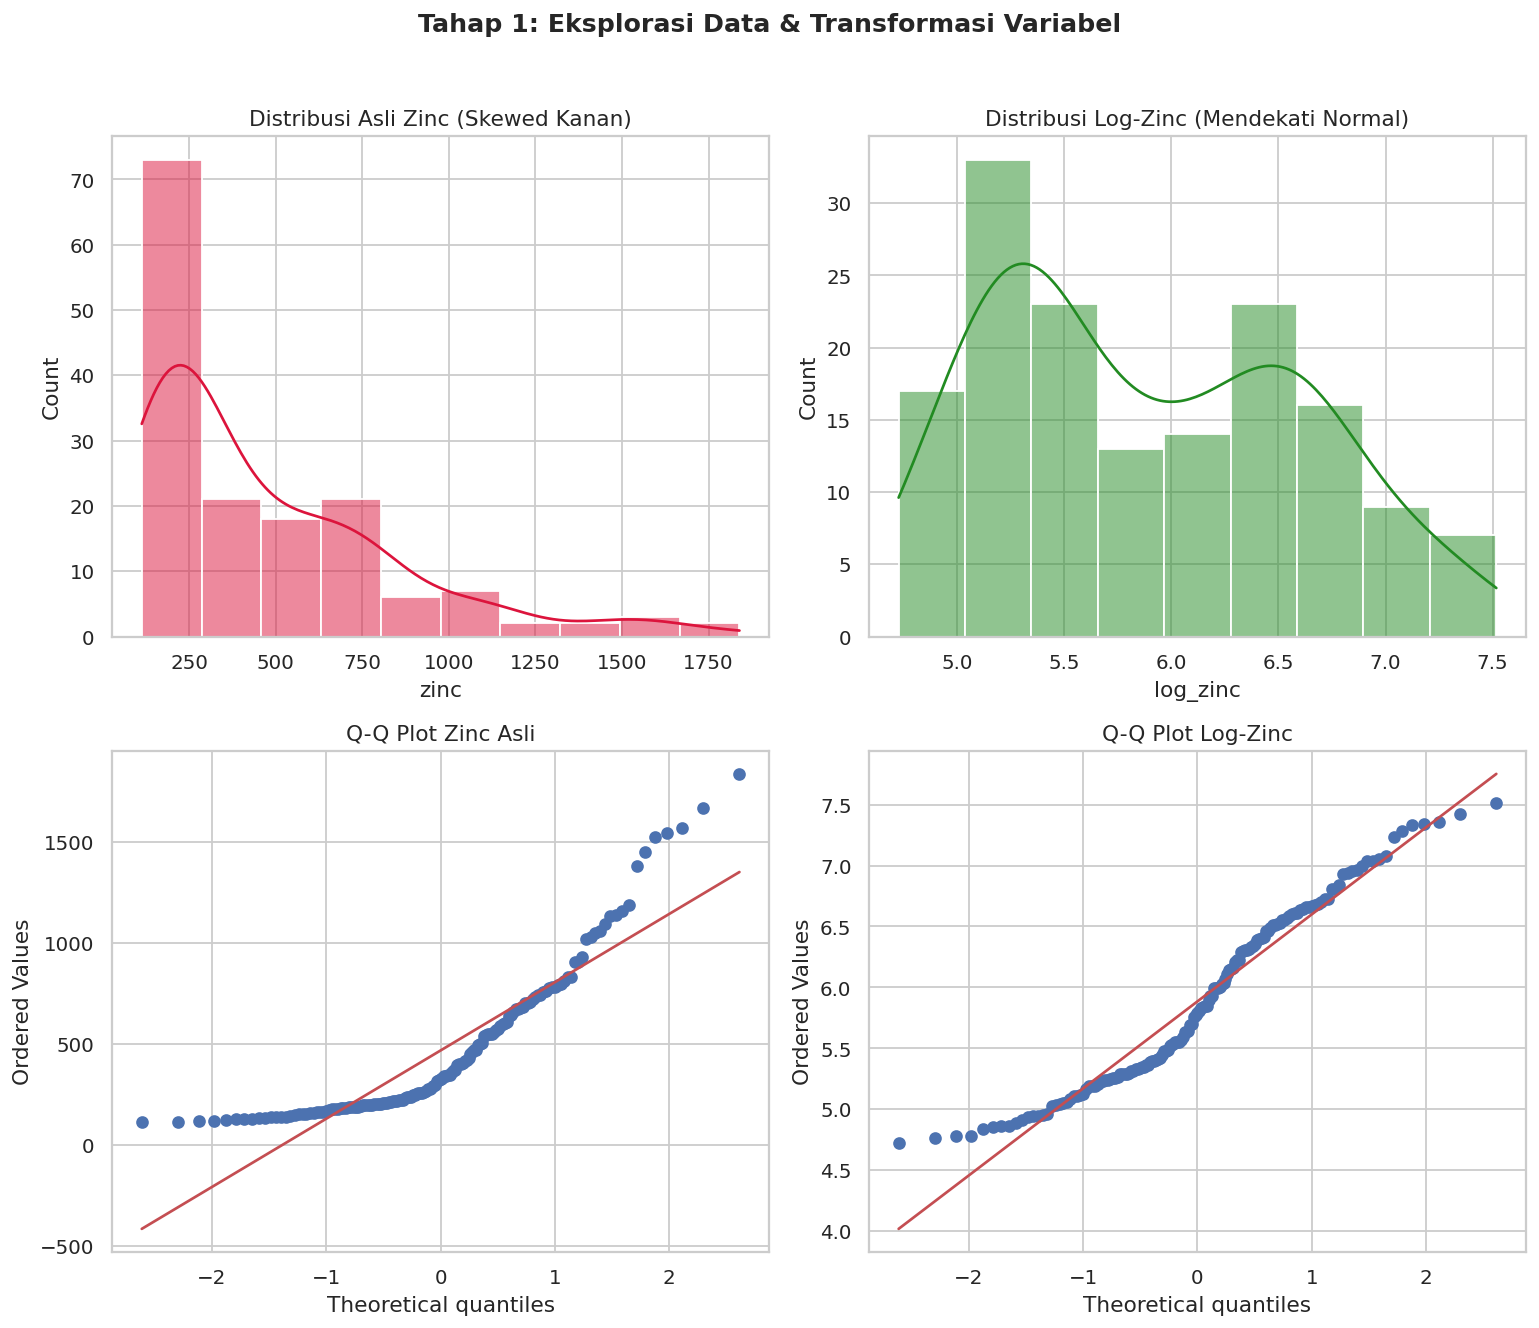

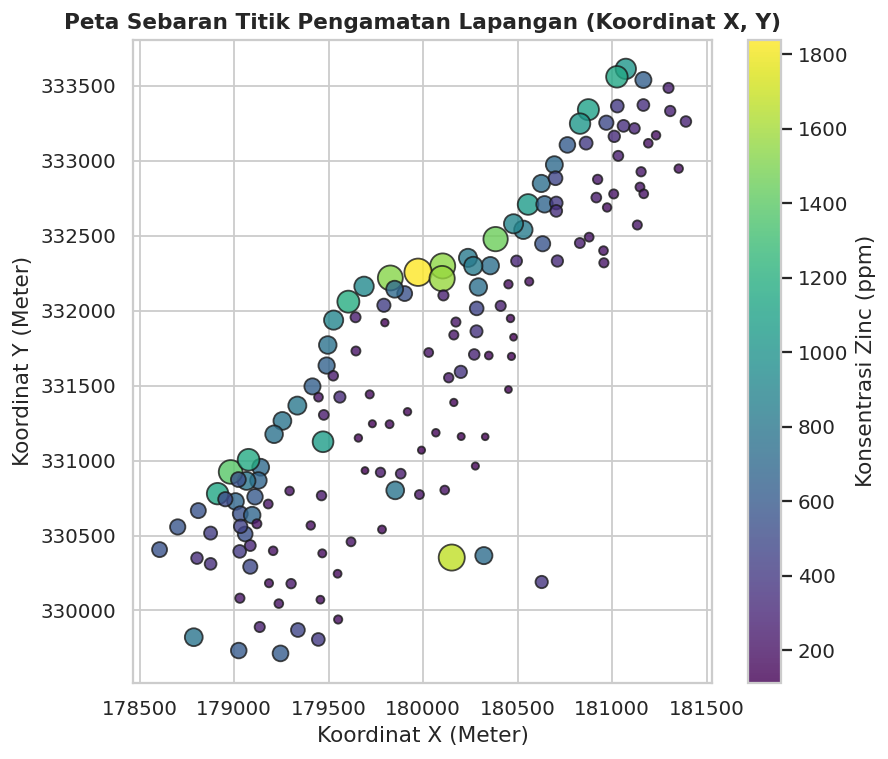

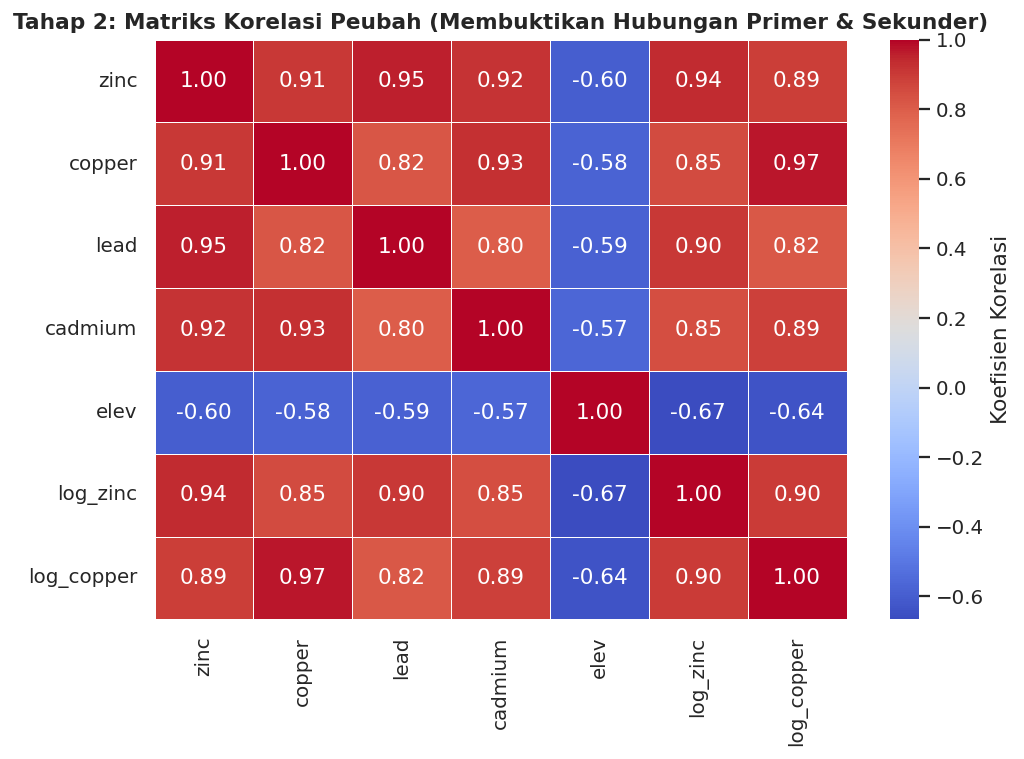

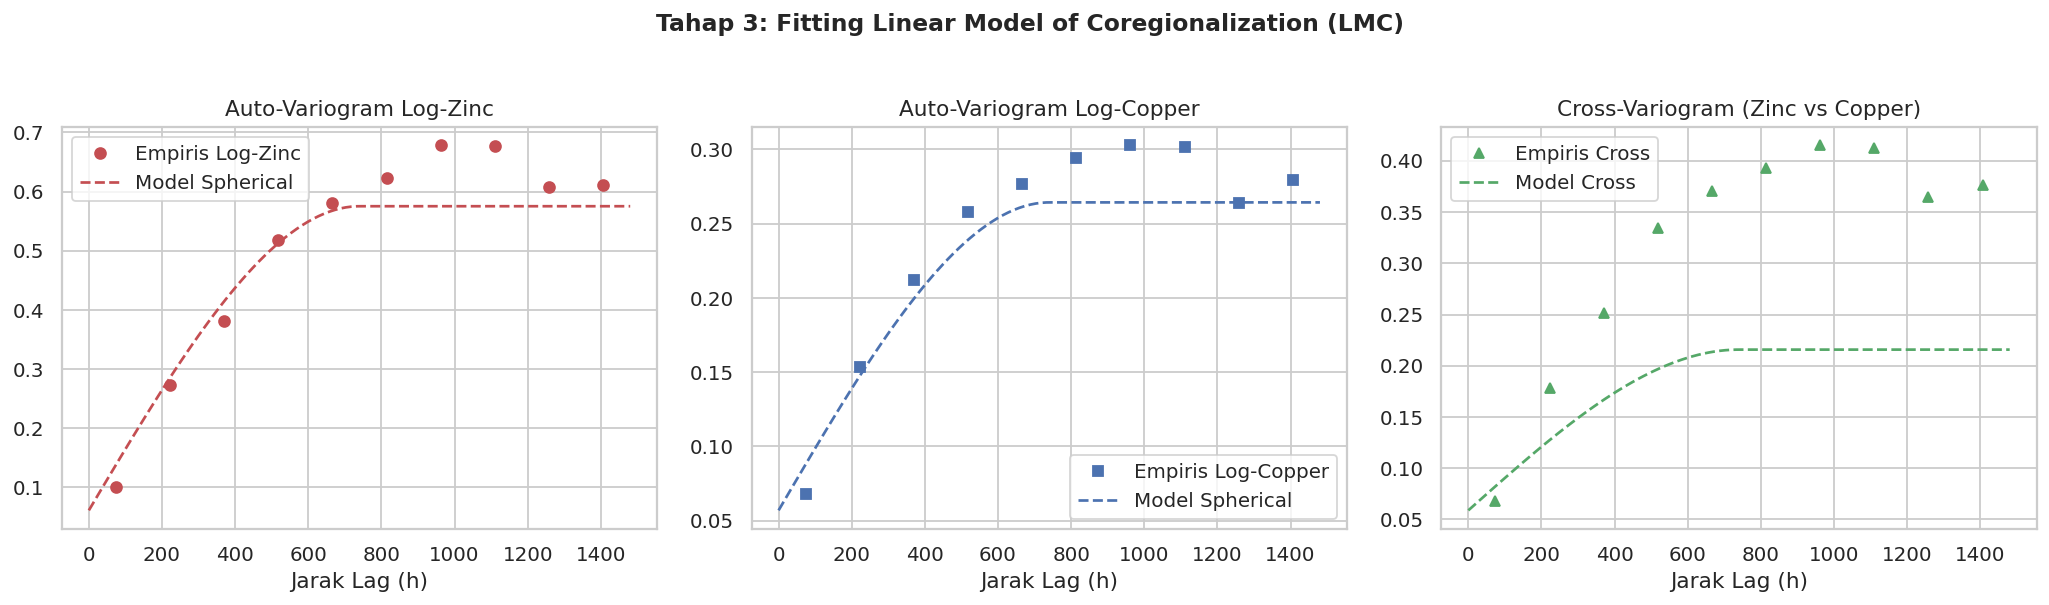


[INFO] Menjalankan Leave-One-Out Cross-Validation (LOOCV)...
 HASIL EVALUASI AKURASI MODEL ORDINARY CO-KRIGING
 Root Mean Squared Error (RMSE) : 222.7454
 Mean Absolute Error (MAE)      : 138.0026
 Koefisien Determinasi (R²)     : 0.6294


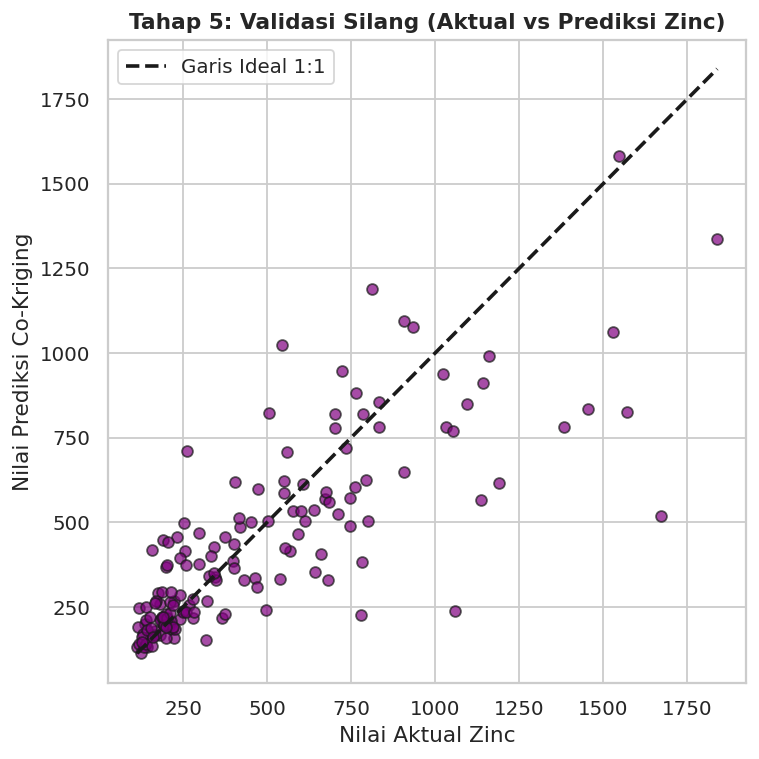


[INFO] Membangun Peta Grid Interpolasi Spasial Co-Kriging...


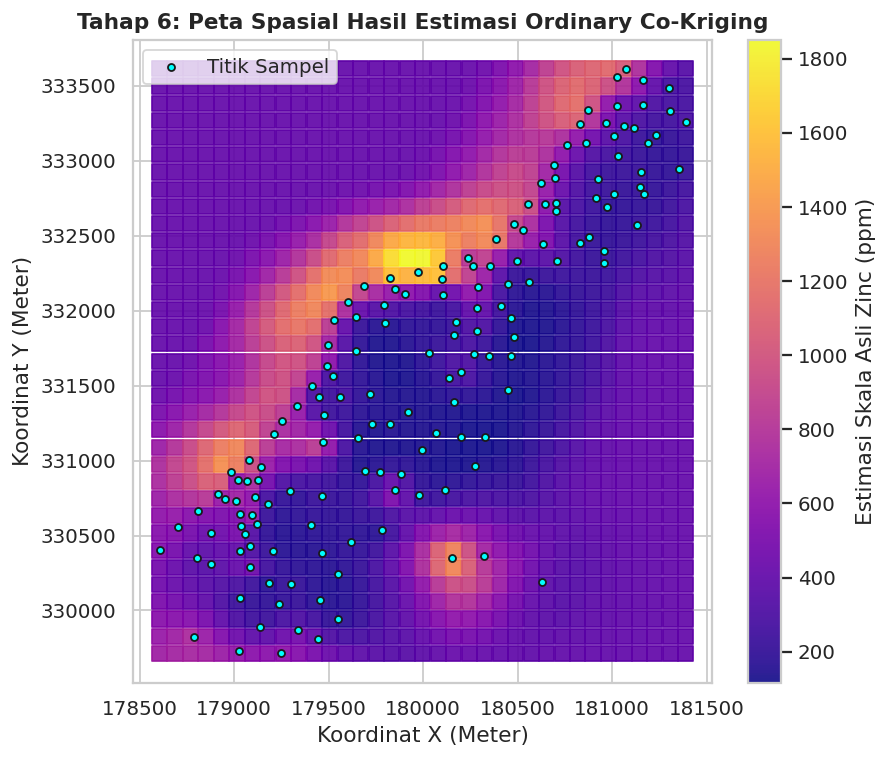

In [7]:
# ==============================================================================
# SKRIP LENGKAP PROFESIONAL: ANALISIS SPASIAL ORDINARY CO-KRIGING (OCK)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
from scipy.stats import shapiro, probplot
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Pengaturan Tema Visualisasi Akademik yang Bersih
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 130

# ==============================================================================
# TAHAP 1: EKSPLORASI DATA AWAL (EDA) & STATISTIK DESKRIPTIF
# ==============================================================================
print("Silakan pilih dan upload file 'meuse.txt' dari perangkat Anda:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_meuse = pd.read_csv(filename).dropna(subset=['zinc', 'copper'])

print(f"\n[INFO] Total data valid dimuat: {len(df_meuse)} baris observasi.")

# Uji Normalitas & Transformasi Logaritmik (Mengatasi Positive Skewness)
df_meuse['log_zinc'] = np.log(df_meuse['zinc'])
df_meuse['log_copper'] = np.log(df_meuse['copper'])

# Visualisasi 1.1: Grafik Distribusi & Q-Q Plot (Sebelum vs Sesudah Transformasi)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df_meuse['zinc'], kde=True, ax=axes[0, 0], color='crimson')
axes[0, 0].set_title('Distribusi Asli Zinc (Skewed Kanan)')

sns.histplot(df_meuse['log_zinc'], kde=True, ax=axes[0, 1], color='forestgreen')
axes[0, 1].set_title('Distribusi Log-Zinc (Mendekati Normal)')

probplot(df_meuse['zinc'], plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot Zinc Asli')

probplot(df_meuse['log_zinc'], plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot Log-Zinc')

plt.suptitle('Tahap 1: Eksplorasi Data & Transformasi Variabel', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Visualisasi 1.2: Peta Sebaran Titik Sampel (Sample Location Map)
plt.figure(figsize=(7, 6))
scatter_loc = plt.scatter(df_meuse['x'], df_meuse['y'], c=df_meuse['zinc'], cmap='viridis', s=df_meuse['zinc']/8, edgecolors='k', alpha=0.8)
plt.colorbar(scatter_loc, label='Konsentrasi Zinc (ppm)')
plt.title('Peta Sebaran Titik Pengamatan Lapangan (Koordinat X, Y)', fontsize=12, fontweight='bold')
plt.xlabel('Koordinat X (Meter)')
plt.ylabel('Koordinat Y (Meter)')
plt.tight_layout()
plt.show()


# ==============================================================================
# TAHAP 2: ANALISIS KORELASI PEUBAH (PRIMER & SEKUNDER)
# ==============================================================================
plt.figure(figsize=(8, 6))
cols_corr = ['zinc', 'copper', 'lead', 'cadmium', 'elev', 'log_zinc', 'log_copper']
corr_matrix = df_meuse[[c for c in cols_corr if c in df_meuse.columns]].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Koefisien Korelasi'})
plt.title('Tahap 2: Matriks Korelasi Peubah (Membuktikan Hubungan Primer & Sekunder)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# ==============================================================================
# TAHAP 3: ANALISIS VARIOGRAFI & LINEAR MODEL OF COREGIONALIZATION (LMC)
# ==============================================================================
coords = df_meuse[['x', 'y']].values
z1_log = df_meuse['log_zinc'].values       # Primer: Log-Zinc
z2_log = df_meuse['log_copper'].values   # Sekunder: Log-Copper

def compute_variograms(coords, z1, z2, n_lags=10, max_dist=None):
    dist_matrix = squareform(pdist(coords))
    if max_dist is None: max_dist = np.max(dist_matrix) / 3.0

    dz1, dz2 = z1[:, None] - z1[None, :], z2[:, None] - z2[None, :]
    g11_mat, g22_mat, g12_mat = 0.5 * (dz1**2), 0.5 * (dz2**2), 0.5 * (dz1 * dz2)

    bins = np.linspace(0, max_dist, n_lags + 1)
    lags = 0.5 * (bins[:-1] + bins[1:])
    g11, g22, g12 = [], [], []

    for i in range(n_lags):
        mask = (dist_matrix >= bins[i]) & (dist_matrix < bins[i+1])
        if np.sum(mask) > 0:
            g11.append(np.mean(g11_mat[mask]))
            g22.append(np.mean(g22_mat[mask]))
            g12.append(np.mean(g12_mat[mask]))
        else:
            g11.append(np.nan); g22.append(np.nan); g12.append(np.nan)
    return lags, np.array(g11), np.array(g22), np.array(g12)

max_d = np.max(pdist(coords)) / 3.0
lags, g11_emp, g22_emp, g12_emp = compute_variograms(coords, z1_log, z2_log, max_dist=max_d)

def spherical(h, a):
    h = np.asarray(h)
    return np.where(h <= a, 1.5 * (h / a) - 0.5 * (h / a)**3, 1.0)

def lmc_loss(params):
    c11_0, c22_0, c12_0, c11_1, c22_1, c12_1, a = params
    # Uji Cauchy-Schwarz untuk memastikan matriks kovarians positif definit
    if (c12_0**2 > c11_0 * c22_0) or (c12_1**2 > c11_1 * c22_1) or (a <= 0): return 1e9

    g11_p = c11_0 + c11_1 * spherical(lags, a)
    g22_p = c22_0 + c22_1 * spherical(lags, a)
    g12_p = c12_0 + c12_1 * spherical(lags, a)

    valid = ~np.isnan(g11_emp)
    return np.sum((g11_emp[valid] - g11_p[valid])**2) + np.sum((g22_emp[valid] - g22_p[valid])**2) + np.sum((g12_emp[valid] - g12_p[valid])**2)

res = minimize(lmc_loss, [0.05, 0.05, 0.0, 0.5, 0.2, 0.1, max_d/2], bounds=[(0,None),(0,None),(None,None),(0,None),(0,None),(None,None),(10,max_d)], method='L-BFGS-B')
c11_0, c22_0, c12_0, c11_1, c22_1, c12_1, range_lmc = res.x

# Visualisasi 3: Grafik LMC (Auto-Variogram & Cross-Variogram)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
h_grid = np.linspace(0, max_d, 100)

axes[0].plot(lags, g11_emp, 'ro', label='Empiris Log-Zinc')
axes[0].plot(h_grid, c11_0 + c11_1 * spherical(h_grid, range_lmc), 'r--', label='Model Spherical')
axes[0].set_title('Auto-Variogram Log-Zinc')
axes[0].set_xlabel('Jarak Lag (h)'); axes[0].legend()

axes[1].plot(lags, g22_emp, 'bs', label='Empiris Log-Copper')
axes[1].plot(h_grid, c22_0 + c22_1 * spherical(h_grid, range_lmc), 'b--', label='Model Spherical')
axes[1].set_title('Auto-Variogram Log-Copper')
axes[1].set_xlabel('Jarak Lag (h)'); axes[1].legend()

axes[2].plot(lags, g12_emp, 'g^', label='Empiris Cross')
axes[2].plot(h_grid, c12_0 + c12_1 * spherical(h_grid, range_lmc), 'g--', label='Model Cross')
axes[2].set_title('Cross-Variogram (Zinc vs Copper)')
axes[2].set_xlabel('Jarak Lag (h)'); axes[2].legend()

plt.suptitle('Tahap 3: Fitting Linear Model of Coregionalization (LMC)', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


# ==============================================================================
# TAHAP 4 & 5: PEMODELAN ORDINARY CO-KRIGING & VALIDASI SILANG (LOOCV)
# ==============================================================================
def get_cov(h, c0, c1, a): return (c0 + c1) - (c0 + c1 * spherical(h, a))

def ock_predict_single(s_coords, z1_s, z2_s, target_coord):
    n = len(s_coords)
    D = squareform(pdist(s_coords))
    C11, C22, C12 = get_cov(D, c11_0, c11_1, range_lmc), get_cov(D, c22_0, c22_1, range_lmc), get_cov(D, c12_0, c12_1, range_lmc)

    K = np.zeros((2*n + 2, 2*n + 2))
    K[0:n, 0:n] = C11; K[0:n, n:2*n] = C12
    K[n:2*n, 0:n] = C12.T; K[n:2*n, n:2*n] = C22
    K[0:n, 2*n] = 1.0; K[2*n, 0:n] = 1.0
    K[n:2*n, 2*n+1] = 1.0; K[2*n+1, n:2*n] = 1.0

    dt = np.sqrt(np.sum((s_coords - target_coord)**2, axis=1))
    c11_t, c12_t = get_cov(dt, c11_0, c11_1, range_lmc), get_cov(dt, c12_0, c12_1, range_lmc)

    k0 = np.zeros(2*n + 2)
    k0[0:n] = c11_t; k0[n:2*n] = c12_t; k0[2*n] = 1.0; k0[2*n+1] = 0.0

    weights = np.linalg.solve(K + np.eye(2*n+2)*1e-5, k0)
    log_pred = np.sum(weights[0:n] * z1_s) + np.sum(weights[n:2*n] * z2_s)
    return np.exp(log_pred) # Back-transformation ke skala asli

print("\n[INFO] Menjalankan Leave-One-Out Cross-Validation (LOOCV)...")
y_true = df_meuse['zinc'].values
y_pred = []

for i in range(len(coords)):
    mask = np.ones(len(coords), dtype=bool)
    mask[i] = False
    p_val = ock_predict_single(coords[mask], z1_log[mask], z2_log[mask], coords[i])
    y_pred.append(p_val)

y_pred = np.array(y_pred)

# Metrik Evaluasi Akurasi
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("="*60)
print(" HASIL EVALUASI AKURASI MODEL ORDINARY CO-KRIGING")
print("="*60)
print(f" Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f" Mean Absolute Error (MAE)      : {mae:.4f}")
print(f" Koefisien Determinasi (R²)     : {r2:.4f}")
print("="*60)

# Visualisasi 4: Scatter Plot Validasi Silang (Aktual vs Prediksi)
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, color='purple', alpha=0.7, edgecolors='k')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2, label='Garis Ideal 1:1')
plt.title('Tahap 5: Validasi Silang (Aktual vs Prediksi Zinc)', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Aktual Zinc')
plt.ylabel('Nilai Prediksi Co-Kriging')
plt.legend()
plt.tight_layout()
plt.show()


# ==============================================================================
# TAHAP 6: PEMBUATAN PETA INTERPOLASI SPASIAL
# ==============================================================================
print("\n[INFO] Membangun Peta Grid Interpolasi Spasial Co-Kriging...")
grid_x = np.linspace(df_meuse['x'].min(), df_meuse['x'].max(), 35)
grid_y = np.linspace(df_meuse['y'].min(), df_meuse['y'].max(), 35)
GX, GY = np.meshgrid(grid_x, grid_y)
G_coords = np.c_[GX.ravel(), GY.ravel()]

predicted_grid = [ock_predict_single(coords, z1_log, z2_log, pt) for pt in G_coords]

# Visualisasi 5: Peta Sebaran Spasial Hasil Prediksi Co-Kriging
plt.figure(figsize=(7, 6))
plt.scatter(G_coords[:, 0], G_coords[:, 1], c=predicted_grid, cmap='plasma', s=70, marker='s', alpha=0.9)
plt.colorbar(label='Estimasi Skala Asli Zinc (ppm)')
plt.scatter(df_meuse['x'], df_meuse['y'], c='cyan', s=15, edgecolors='k', label='Titik Sampel')
plt.title('Tahap 6: Peta Spasial Hasil Estimasi Ordinary Co-Kriging', fontsize=12, fontweight='bold')
plt.xlabel('Koordinat X (Meter)')
plt.ylabel('Koordinat Y (Meter)')
plt.legend()
plt.tight_layout()
plt.show()